**Detectability of Gravitational Wave**

In [6]:
import h5py as h5py

path = "/Users/ffara/Desktop/LML/astrostatistics_bicocca_2025/exercise/sample_2e7_design_precessing_higherordermodes_3detectors.h5"
with h5py.File(path, 'r') as f:
    fin = {key: f[key][()] for key in f.keys()}

In [7]:
data = {k: v[:10] for k, v in fin.items()}
data

{'chi1x': array([-0.3072008 , -0.7347119 , -0.05783062,  0.01525973, -0.01673118,
         0.4443011 , -0.06936265,  0.19165326,  0.12483078, -0.44993785]),
 'chi1y': array([ 0.27616489, -0.49849269, -0.70379617, -0.20246744,  0.00784786,
        -0.31301459, -0.07127225, -0.1989721 ,  0.06914018, -0.64986947]),
 'chi1z': array([-0.43075952, -0.29816229, -0.35451167, -0.49276816,  0.00500682,
        -0.05733308,  0.0630508 ,  0.08846434, -0.00856445,  0.08961064]),
 'chi2x': array([-0.1611142 ,  0.05753236, -0.21553765, -0.23703338,  0.14751943,
         0.22085572, -0.3973216 , -0.19430081,  0.21015512,  0.20821135]),
 'chi2y': array([-0.09233378, -0.8449919 ,  0.01632286, -0.3653626 ,  0.23187921,
        -0.05548155, -0.05334784, -0.22864555, -0.20909876, -0.26666301]),
 'chi2z': array([-0.41464697,  0.01470768,  0.13054284, -0.87619207,  0.08671622,
         0.24863691,  0.21687095,  0.29429637, -0.49862889,  0.19589229]),
 'dec': array([-0.32967056,  0.52673981,  0.3157986 ,  0.4

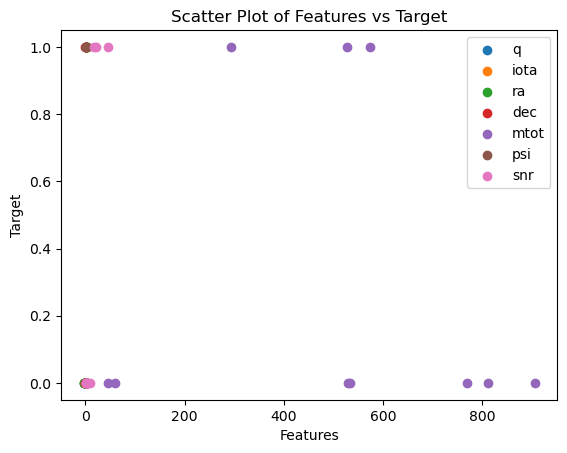

In [21]:
import numpy as np
import matplotlib.pyplot as plt

Y = data['det']

X = np.column_stack([
    data['q'],
    data['iota'],
    data['ra'],
    data['dec'],
    data['mtot'],
    data['psi'],
    data['snr'],
])

plt.scatter(X[:, 0], Y, label='q')
plt.scatter(X[:, 1], Y, label='iota')
plt.scatter(X[:, 2], Y, label='ra')
plt.scatter(X[:, 3], Y, label='dec')
plt.scatter(X[:, 4], Y, label='mtot')
plt.scatter(X[:, 5], Y, label='psi')
plt.scatter(X[:, 6], Y, label='snr')
plt.xlabel('Features')
plt.ylabel('Target')
plt.title('Scatter Plot of Features vs Target')
plt.legend()
plt.show()

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)
print("Train set score Random Forest: ", rf.score(X_train, Y_train))

Train set score Random Forest:  1.0
